# Experiment

Erstellt und Trainiert einen Baseline-Agenten und einen Counting-Agenten auf der gemeinsamen Blackjack-Umgebung.

In [1]:
from collections import defaultdict
from tqdm import tqdm
import gymnasium as gym
import numpy as np
import pickle

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "blackjack_env.py").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from blackjack_env import BlackjackEnv
from agents.q_learning_agent import QLearningBlackjackAgent

In [2]:
def baseline_state_key(obs) -> tuple[int, int, int]:
    player_total, dealer_upcard, usable_ace = obs[:3]

    return (
        int(player_total),
        int(dealer_upcard),
        int(usable_ace)
    )

def counting_state_key(obs: np.ndarray) -> tuple[int, int, int, int, int, int]:
    player_total, dealer_upcard, usable_ace, running_count, true_count, cards_remaining = obs
    count_bucket = int(np.clip(np.round(running_count), -20, 20))
    true_count_bucket = int(np.clip(np.round(true_count), -10, 10))
    shoe_bucket = int(np.clip(np.round(cards_remaining / 52.0), 0, 6))

    return (
        int(player_total),
        int(dealer_upcard),
        int(usable_ace),
        count_bucket,
        true_count_bucket,
        shoe_bucket,
    )


class BaselineBlackjackAgent(QLearningBlackjackAgent):
    def __init__(
            self, 
            env: gym.Env,
            **kwargs):
        
        super().__init__(
            env=env,
            state_encoder=baseline_state_key,
            **kwargs,
        )
        
class CountingBlackjackAgent(QLearningBlackjackAgent):
    def __init__(
            self, 
            env: gym.Env,
            **kwargs):
        
        super().__init__(
            env=env,
            state_encoder=counting_state_key,
            **kwargs,
        )

## Creating the Agents

In [3]:
SEED = 42
N_EPISODES = 10_000

agent_config = {
    "learning_rate": 0.01,
    "initial_epsilon": 1.0,
    "final_epsilon": 0.1,
    "epsilon_decay": (1.0 - 0.1) / (N_EPISODES * 0.6),
}

def make_env(seed: int, n_episodes: int):
    env = BlackjackEnv(
        num_decks=6,
        penetration=0.75,
        stand_on_soft_17=True,
    )

    env = gym.wrappers.RecordEpisodeStatistics(
        env,
        buffer_length=n_episodes,
    )

    env.reset(seed=seed)
    env.action_space.seed(seed)

    return env

agents = {
    "baseline": BaselineBlackjackAgent(
        env=make_env(SEED, N_EPISODES),
        **agent_config,
    ),
    "counting": CountingBlackjackAgent(
        env=make_env(SEED, N_EPISODES),
        **agent_config,
    ),
}

## Training the Agents

In [4]:
# Trainieren der Agenten
for name, agent in agents.items():
    print(f"Starte Training für {name} Agent...")
    agent.train(n_episodes=N_EPISODES, base_seed=SEED)
    print(f"Training für {name} Agent erfolgreich beendet.\n")

Starte Training für baseline Agent...


Training für baseline Agent erfolgreich beendet.

Starte Training für counting Agent...


Training für counting Agent erfolgreich beendet.



## Analyzing Training Results

In [5]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

def get_moving_stats(arr, window: int):
    arr = np.asarray(arr).flatten()
    if len(arr) == 0:
        return arr, arr, np.arange(0)

    min_periods = max(1, window // 10)
    series = pd.Series(arr)

    means = series.rolling(window=window, min_periods=min_periods).mean().to_numpy()
    stds = series.rolling(window=window, min_periods=min_periods).std().to_numpy()
    stds = np.nan_to_num(stds)

    return means, stds, np.arange(len(arr))

def plot_reward_comparison(agents: dict, window: int = 1000):
    plt.figure(figsize=(12, 5))

    for name, agent in agents.items():
        rewards = np.asarray(agent.episode_rewards)
        means, stds, x = get_moving_stats(rewards, window)

        # Hauptlinie für den gleitenden Mittelwert
        line, = plt.plot(x, means, label=name, linewidth=2)

        # Transparentes Band für die echte Standardabweichung
        plt.fill_between(
            x,
            means - stds,
            means + stds,
            color=line.get_color(),
            alpha=0.04,
        )

    plt.title("Episode Reward Comparison (with Std Dev Band)", fontsize=14, fontweight='bold')
    plt.xlabel("Episode", fontsize=12)
    plt.ylabel("Average Reward", fontsize=12)
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend(fontsize=11)
    plt.tight_layout()
    plt.show()


def plot_td_error_comparison(agents: dict, window: int = 5000):
    plt.figure(figsize=(12, 5))

    for name, agent in agents.items():
        td_errors = np.asarray(agent.training_error)
        means, stds, x = get_moving_stats(td_errors, window)

        line, = plt.plot(x, means, label=name, linewidth=2)
        plt.fill_between(
            x,
            means - stds,
            means + stds,
            color=line.get_color(),
            alpha=0.1,
        )

    plt.title("TD Error Comparison", fontsize=14, fontweight='bold')
    plt.xlabel("Step (Transition)", fontsize=12)
    plt.ylabel("Average TD Error", fontsize=12)
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend(fontsize=11)
    plt.tight_layout()
    plt.show()


def plot_all(agents: dict, reward_window: int = 1000, td_window: int = 5000):
    fig, axs = plt.subplots(1, 2, figsize=(16, 6))

    for name, agent in agents.items():
        # Links: Rewards (Ohne Hintergrundband)
        rewards = np.asarray(agent.episode_rewards)
        r_means, _, x_r = get_moving_stats(rewards, reward_window)
        axs[0].plot(x_r, r_means, label=name, linewidth=2.5) # Linie etwas dicker für bessere Sichtbarkeit

        # Rechts: TD Error (Ohne Hintergrundband)
        td_errors = np.asarray(agent.training_error)
        t_means, _, x_t = get_moving_stats(td_errors, td_window)
        axs[1].plot(x_t, t_means, label=name, linewidth=2.5)

    axs[0].set_title("Episode Rewards (Geglättet)", fontsize=13, fontweight='bold')
    axs[0].set_xlabel("Episode", fontsize=11)
    axs[0].set_ylabel("Reward", fontsize=11)
    axs[0].grid(True, linestyle="--", alpha=0.5)
    axs[0].legend(fontsize=10)

    axs[1].set_title("TD Error Verlauf", fontsize=13, fontweight='bold')
    axs[1].set_xlabel("Step", fontsize=11)
    axs[1].set_ylabel("TD Error", fontsize=11)
    axs[1].grid(True, linestyle="--", alpha=0.5)
    axs[1].legend(fontsize=10)

    plt.tight_layout()
    plt.show()

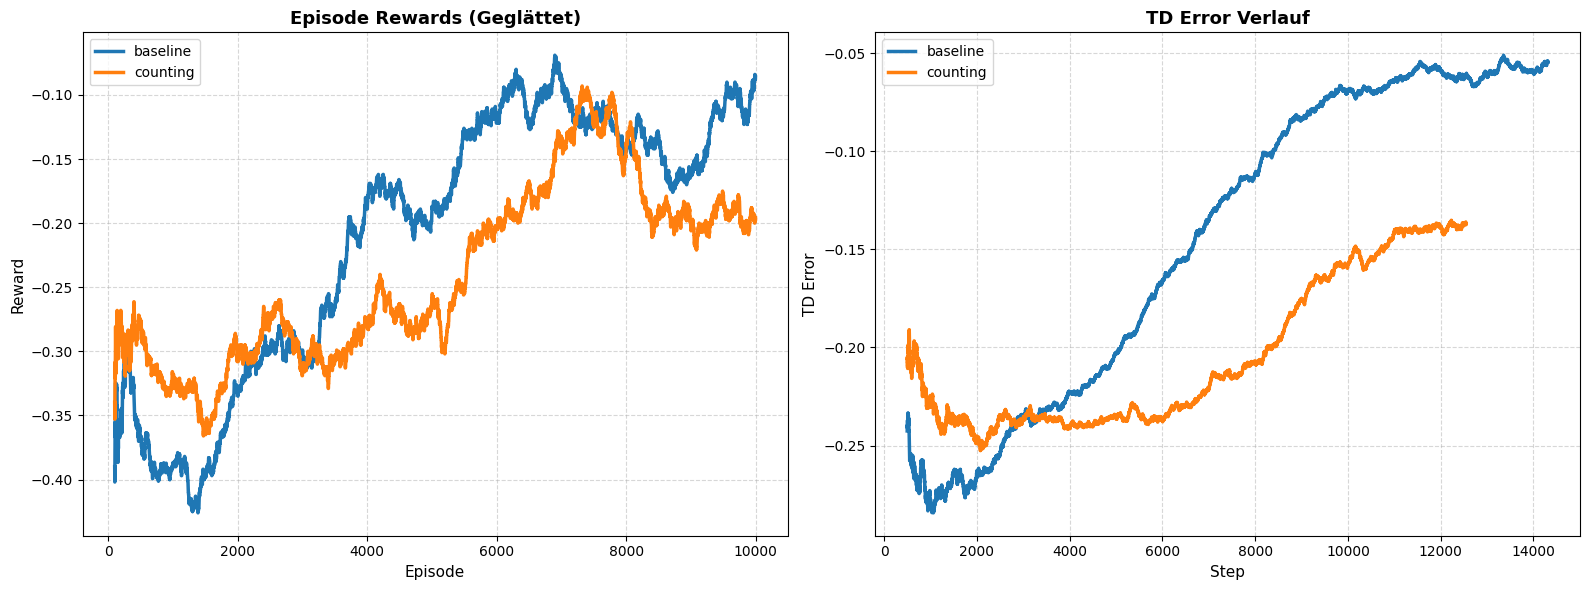

In [6]:
plot_all(agents)

## Test new Analysis

## Saving the Trained Agents

In [7]:
from datetime import datetime

# Eindeutigen Zeitstempel für diesen gesamten Run generieren (Format: YYYYMMDD_HHMMSS)
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Zielordner definieren (Best Practice: Ein eigener Unterordner für Modelle)
MODEL_DIR = PROJECT_ROOT / "models"

for name, agent in agents.items():
    print(f"Saving {name} agent...")
    
    # Dateiname mit Modellspezifikation und Zeitstempel
    filename = f"{name}_agent_{timestamp}.pkl"
    path = MODEL_DIR / filename
    
    # Aufruf der korrigierten internen Save-Methode
    agent.save(path, label=f"{name}_{timestamp}")
    print(f"-> Erfolgreich gespeichert unter: {path}")

Saving baseline agent...
-> Erfolgreich gespeichert unter: E:\tomni\Documents\01_Code\ml-blackjack\models\baseline_agent_20260603_120633.pkl
Saving counting agent...
-> Erfolgreich gespeichert unter: E:\tomni\Documents\01_Code\ml-blackjack\models\counting_agent_20260603_120633.pkl


## Testing